In this file, we
1. automate the data preprocessing and
2. create multiplex ordinal transition networks for a certain time window in a file (edge list + adjacency matrix)

Updates from the last :
- Since referencing from average might seem to affect on the results, referencing is removed.

Results:
- All factors represent more obvious differences.
- Removing average referencing significantly increases the contrast between ictal and interictal dynamics.
- Without referencing, central and posterior regions show much lower entropy and higher self-loop ratios, indicating stronger and more persistent seizure patterns.
- In contrast, frontal regions exhibit increased entropy, suggesting more complex or propagating dynamics.
- This suggests that referencing may suppress intrinsic seizure-related temporal structures.

In [6]:
#!pip install ts2vg
#!pip install mne
#%cd /content
#!git clone https://github.com/ionikim/epilepsy_pediatrics_EEG.git
#%cd /content/epilepsy_pediatrics_EEG
%cd C:/Users/marin/OneDrive/Dokumente/Uni/MSc_DNs_Fribourg/FS26/Social_Media_Analytics/git/
from pathlib import Path
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
import json
import scipy.sparse as sp
from scipy.sparse import save_npz
from itertools import permutations
from collections import Counter
import math

C:\Users\marin\OneDrive\Dokumente\Uni\MSc_DNs_Fribourg\FS26\Social_Media_Analytics\git


In [7]:
RAW_DIR = Path("data/raw")

PROCESSED_DIR = Path("data/processed")
LABELED_DIR   = PROCESSED_DIR / "labeled_signals"
FILEMETA_DIR  = PROCESSED_DIR / "file_metadata"

WINDOWS_DIR   = Path("data/windows")
WINDOWSIG_DIR = WINDOWS_DIR / "signals"
WINDOWMETA_DIR = WINDOWS_DIR / "metadata"

for d in [LABELED_DIR, FILEMETA_DIR, WINDOWSIG_DIR, WINDOWMETA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

In [8]:
print("CWD:", Path.cwd())
print("RAW_DIR exists:", Path("data/raw").exists())
print("Files in raw:")
for p in Path("data/raw").glob("*"):
    print(p.name)

CWD: C:\Users\marin\OneDrive\Dokumente\Uni\MSc_DNs_Fribourg\FS26\Social_Media_Analytics\git
RAW_DIR exists: True
Files in raw:
.gitattributes
.gitkeep
chb01_03.edf
chb01_03.edf.seizures
chb01_10.edf


In [9]:
def save_json(data, out_path):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)

In [10]:
def get_seizure_period(annotation_file):
    with open(annotation_file, "rb") as f:
        byte_array = f.read()

    start = int(bin(byte_array[38])[2:] + bin(byte_array[41])[2:], 2)
    length = byte_array[49]
    return start, length

In [11]:
def process_edf_with_labels(edf_file, seizure_file=None):
    edf_file = Path(edf_file)
    seizure_file = Path(seizure_file) if seizure_file is not None else None

    raw = mne.io.read_raw_edf(str(edf_file), preload=True, verbose=False)
    raw.filter(1., 45.)

    electrode_names = raw.ch_names
    sfreq = raw.info["sfreq"]
    n_samples = len(raw.times)
    time_marks = np.arange(n_samples) / sfreq
    electrode_data = raw.get_data()


    df = pd.DataFrame(electrode_data.T, columns=electrode_names)
    df.index = time_marks
    df.index.name = "Time (s)"

    seizure_start = None
    seizure_length = None
    seizure_end = None

    if seizure_file is not None:
        seizure_start, seizure_length = get_seizure_period(seizure_file)
        seizure_end = seizure_start + seizure_length

        df["label"] = df.index.map(
            lambda t: "ictal" if seizure_start <= t <= seizure_end else "interictal"
        )
        has_seizure = True
    else:
        df["label"] = "interictal"
        has_seizure = False

    file_meta = {
        "edf_file": str(edf_file),
        "seizure_file": str(seizure_file) if seizure_file else None,
        "sampling_rate_hz": float(sfreq),
        "channel_names": list(electrode_names),
        "n_channels": int(len(electrode_names)),
        "n_samples": int(n_samples),
        "duration_s": float(n_samples / sfreq),
        "has_seizure": bool(has_seizure),
        "seizure_start_s": float(seizure_start) if seizure_start is not None else None,
        "seizure_length_s": float(seizure_length) if seizure_length is not None else None,
        "seizure_end_s": float(seizure_end) if seizure_end is not None else None,
    }

    return df, file_meta

In [12]:
def extract_window(df, window_size_s=10, mode="ictal", strategy="first"):
    sfreq = int(round(1 / (df.index[1] - df.index[0])))
    window_size_samples = window_size_s * sfreq

    if mode == "ictal":
        indices = np.where(df["label"] == "ictal")[0]
    elif mode == "interictal":
        indices = np.where(df["label"] == "interictal")[0]
    else:
        raise ValueError("mode must be 'ictal' or 'interictal'")

    if len(indices) == 0:
        raise ValueError(f"No {mode} samples found.")

    valid_starts = [
        idx for idx in indices
        if idx + window_size_samples <= len(df)
        and (df["label"].iloc[idx: idx + window_size_samples] == mode).all()
    ]

    if not valid_starts:
        raise ValueError(f"No contiguous {mode} block of {window_size_s}s found.")

    if mode == "ictal":
        onset_idx = int(indices[0])
        offset_idx = int(indices[-1])

        if strategy == "first":
            start_idx = int(valid_starts[0])
        elif strategy == "middle":
            center_idx = (onset_idx + offset_idx) // 2
            start_idx = center_idx - (window_size_samples // 2)
        elif strategy == "last":
            start_idx = offset_idx - window_size_samples + 1
        else:
            raise ValueError("For ictal, strategy must be 'first', 'middle', or 'last'")

        if start_idx < 0 or start_idx + window_size_samples > len(df):
            raise ValueError(f"Invalid ictal window for strategy='{strategy}'")

        if not (df["label"].iloc[start_idx: start_idx + window_size_samples] == "ictal").all():
            raise ValueError(f"Ictal window for strategy='{strategy}' is not fully ictal.")

    else:  # interictal
        if strategy == "first":
            start_idx = int(valid_starts[0])
        elif strategy == "middle":
            start_idx = int(valid_starts[len(valid_starts) // 2])
        elif strategy == "last":
            start_idx = int(valid_starts[-1])
        else:
            raise ValueError("For interictal, strategy must be 'first', 'middle', or 'last'")

    window = df.iloc[start_idx: start_idx + window_size_samples]
    return window, start_idx

In [13]:
def make_signal_id(edf_path):
    return Path(edf_path).stem

In [14]:
def process_ictal_interictal_pair(
    ictal_edf,
    ictal_seizure_file,
    interictal_edf,
    window_size_s=10,
    ictal_strategy="middle",
    interictal_strategy="middle"
):
    ictal_edf = Path(ictal_edf)
    ictal_seizure_file = Path(ictal_seizure_file)
    interictal_edf = Path(interictal_edf)

    # -------------------------
    # 1) ictal source
    # -------------------------
    ictal_df, ictal_meta = process_edf_with_labels(ictal_edf, ictal_seizure_file)
    ictal_id = make_signal_id(ictal_edf)

    ictal_labeled_out = LABELED_DIR / f"{ictal_id}.parquet"
    ictal_df.to_parquet(ictal_labeled_out)

    ictal_meta_out = FILEMETA_DIR / f"{ictal_id}.json"
    save_json(ictal_meta, ictal_meta_out)

    ictal_window, ictal_start_idx = extract_window(
        ictal_df,
        window_size_s=window_size_s,
        mode="ictal",
        strategy=ictal_strategy
    )

    ictal_window_id = f"window_ictal_{ictal_id}"
    ictal_window_out = WINDOWSIG_DIR / f"{ictal_window_id}.parquet"
    ictal_window.to_parquet(ictal_window_out)

    # -------------------------
    # 2) interictal source
    # -------------------------
    interictal_df, interictal_meta = process_edf_with_labels(interictal_edf, seizure_file=None)
    interictal_id = make_signal_id(interictal_edf)

    interictal_labeled_out = LABELED_DIR / f"{interictal_id}.parquet"
    interictal_df.to_parquet(interictal_labeled_out)

    interictal_meta_out = FILEMETA_DIR / f"{interictal_id}.json"
    save_json(interictal_meta, interictal_meta_out)

    interictal_window, interictal_start_idx = extract_window(
        interictal_df,
        window_size_s=window_size_s,
        mode="interictal",
        strategy=interictal_strategy
    )

    interictal_window_id = f"window_interictal_{interictal_id}"
    interictal_window_out = WINDOWSIG_DIR / f"{interictal_window_id}.parquet"
    interictal_window.to_parquet(interictal_window_out)

    # -------------------------
    # 3) window metadata
    # -------------------------
    ictal_sfreq = int(round(1 / (ictal_df.index[1] - ictal_df.index[0])))
    interictal_sfreq = int(round(1 / (interictal_df.index[1] - interictal_df.index[0])))

    windows_index = pd.DataFrame([
        {
            "window_id": ictal_window_id,
            "source_edf": str(ictal_edf),
            "label": "ictal",
            "selection_rule": ictal_strategy,
            "start_idx": ictal_start_idx,
            "end_idx": ictal_start_idx + len(ictal_window) - 1,
            "start_time_s": float(ictal_window.index[0]),
            "end_time_s": float(ictal_window.index[-1]),
            "n_samples": int(len(ictal_window)),
            "window_size_s": int(window_size_s),
            "sampling_rate_hz": float(ictal_sfreq),
        },
        {
            "window_id": interictal_window_id,
            "source_edf": str(interictal_edf),
            "label": "interictal",
            "selection_rule": interictal_strategy,
            "start_idx": interictal_start_idx,
            "end_idx": interictal_start_idx + len(interictal_window) - 1,
            "start_time_s": float(interictal_window.index[0]),
            "end_time_s": float(interictal_window.index[-1]),
            "n_samples": int(len(interictal_window)),
            "window_size_s": int(window_size_s),
            "sampling_rate_hz": float(interictal_sfreq),
        }
    ])

    windows_index_out = WINDOWMETA_DIR / "windows_index.csv"
    windows_index.to_csv(windows_index_out, index=False)

    # -------------------------
    # 4) processing log save
    # -------------------------
    processing_log = pd.DataFrame([
        {
            "source_type": "ictal",
            "edf_file": str(ictal_edf),
            "annotation_file": str(ictal_seizure_file),
            "status": "success",
            "message": "ictal window extracted successfully",
            "saved_labeled_df": str(ictal_labeled_out),
            "saved_window": str(ictal_window_out),
            "saved_metadata": str(ictal_meta_out),
        },
        {
            "source_type": "interictal",
            "edf_file": str(interictal_edf),
            "annotation_file": None,
            "status": "success",
            "message": "interictal window extracted successfully",
            "saved_labeled_df": str(interictal_labeled_out),
            "saved_window": str(interictal_window_out),
            "saved_metadata": str(interictal_meta_out),
        }
    ])

    processing_log_out = PROCESSED_DIR / "processing_log.csv"
    processing_log.to_csv(processing_log_out, index=False)

    # -------------------------
    # 5) print
    # -------------------------
    print("\n=== Ictal source ===")
    print("EDF file               :", ictal_edf)
    print("Seizure annotation     :", ictal_seizure_file)
    print("Saved labeled signal   :", ictal_labeled_out)
    print("Saved file metadata    :", ictal_meta_out)
    print("Saved window           :", ictal_window_out)
    print("Window ID              :", ictal_window_id)
    print("Start time (s)         :", float(ictal_window.index[0]))
    print("End time (s)           :", float(ictal_window.index[-1]))

    print("\n=== Interictal source ===")
    print("EDF file               :", interictal_edf)
    print("Saved labeled signal   :", interictal_labeled_out)
    print("Saved file metadata    :", interictal_meta_out)
    print("Saved window           :", interictal_window_out)
    print("Window ID              :", interictal_window_id)
    print("Strategy               :", interictal_strategy)
    print("Start time (s)         :", float(interictal_window.index[0]))
    print("End time (s)           :", float(interictal_window.index[-1]))

    print("\nSaved window index     :", windows_index_out)
    print("Saved processing log   :", processing_log_out)

    return {
        "ictal_df": ictal_df,
        "interictal_df": interictal_df,
        "ictal_window": ictal_window,
        "interictal_window": interictal_window,
        "windows_index": windows_index,
        "processing_log": processing_log,
    }

In [15]:
result = process_ictal_interictal_pair(
    ictal_edf=RAW_DIR / "chb01_03.edf",
    ictal_seizure_file=RAW_DIR / "chb01_03.edf.seizures",
    interictal_edf=RAW_DIR / "chb01_10.edf",
    window_size_s=10,
    ictal_strategy="middle",
    interictal_strategy="middle"
)

C:\Users\marin\AppData\Local\Temp\ipykernel_62672\764959079.py:5: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(str(edf_file), preload=True, verbose=False)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 845 samples (3.301 s)



C:\Users\marin\AppData\Local\Temp\ipykernel_62672\764959079.py:5: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(str(edf_file), preload=True, verbose=False)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 845 samples (3.301 s)


=== Ictal source ===
EDF file               : data\raw\chb01_03.edf
Seizure annotation     : data\raw\chb01_03.edf.seizures
Saved labeled signal   : data\processed\labeled_signals\chb01_03.parquet
Saved file metadata    : data\processed\file_metadata\chb01_03.json
Saved window           : data\windows\signals\window_ictal_chb01_03.parquet
Window ID              : window_ictal_chb01_03
Start time (s)         : 3011.0
End time (s)      

In [16]:
def make_ordinal_pattern_vocab(order):
    """
    All possible ordinal patterns for given order.
    Example: order=3 -> 6 patterns
    """
    return list(permutations(range(order)))


def extract_ordinal_patterns(signal, order=3, delay=1):
    """
    Convert 1D signal into ordinal pattern sequence.

    Returns
    -------
    patterns : list of tuple
        ordinal patterns
    pattern_time_idx : list of int
        time index where each pattern starts
    """
    signal = np.asarray(signal, dtype=float)
    n = len(signal)
    span = (order - 1) * delay + 1

    patterns = []
    pattern_time_idx = []

    if n < span:
        return patterns, pattern_time_idx

    for i in range(n - span + 1):
        window = signal[i : i + span : delay]
        pattern = tuple(np.argsort(window, kind="mergesort"))
        patterns.append(pattern)
        pattern_time_idx.append(i)

    return patterns, pattern_time_idx


def permutation_entropy_from_patterns(patterns, order=3):
    """
    Normalized permutation entropy from ordinal patterns.
    """
    if len(patterns) == 0:
        return np.nan

    counts = Counter(patterns)
    probs = np.array(list(counts.values()), dtype=float)
    probs = probs / probs.sum()

    pe = -(probs * np.log2(probs)).sum()
    max_pe = np.log2(math.factorial(order))

    return float(pe / max_pe) if max_pe > 0 else np.nan


def make_multiplex_ordinal_node_table(window_df, graph_label, order=3, delay=1):
    """
    Each node = one ordinal pattern state in one electrode(layer).
    NOT one timepoint anymore.
    """
    electrode_cols = [c for c in window_df.columns if c != "label"]
    vocab = make_ordinal_pattern_vocab(order)
    vocab_index = {pat: idx for idx, pat in enumerate(vocab)}

    rows = []
    for electrode in electrode_cols:
        signal = window_df[electrode].to_numpy()
        patterns, _ = extract_ordinal_patterns(signal, order=order, delay=delay)
        unique_patterns = sorted(set(patterns), key=lambda x: vocab_index[x])

        for pat in unique_patterns:
            pat_str = "".join(map(str, pat))
            node_name = f"{electrode}_ord_{pat_str}"
            rows.append({
                "Id": node_name,
                "Label": node_name,
                "electrode": electrode,
                "pattern": pat_str,
                "pattern_rank": int(vocab_index[pat]),
                "layer": electrode,
                "graph_label": graph_label
            })

    return pd.DataFrame(rows)


def prune_edges_by_quantile(edge_rows, keep_ratio=0.05):
    """
    edge_rows: list of dicts, each dict must contain 'weight'
    keep_ratio=0.05 means keep top 5% highest-weight edges
    """
    if edge_rows is None or len(edge_rows) == 0:
        return []

    if keep_ratio is None:
        return edge_rows

    if not (0 < keep_ratio <= 1):
        raise ValueError("keep_ratio must be in (0, 1].")

    edge_df = pd.DataFrame(edge_rows)

    if "weight" not in edge_df.columns:
        raise ValueError("'weight' column not found in edge_rows.")

    threshold = edge_df["weight"].quantile(1 - keep_ratio)
    pruned_df = edge_df[edge_df["weight"] >= threshold].copy()

    return pruned_df.to_dict("records")


def build_multiplex_ordinal_network(window_df, order=3, delay=1, intra_keep_ratio=None):
    """
    Build multiplex ordinal transition network.

    Node:
        one ordinal pattern per electrode
    Intra-layer edge:
        transition between consecutive ordinal patterns within same electrode
    Inter-layer edge:
        same ordinal pattern shared across electrodes (optional coupling)
    """
    electrode_cols = [c for c in window_df.columns if c != "label"]

    if len(electrode_cols) == 0:
        raise ValueError("No electrode columns found. 'window_df' seems empty or only has 'label'.")

    vocab = make_ordinal_pattern_vocab(order)
    vocab_index = {pat: idx for idx, pat in enumerate(vocab)}

    node_rows = []
    intra_rows = []
    inter_rows = []
    layer_info = {}

    node_index = {}
    node_labels = []

    # -----------------------------
    # 1) build nodes + intra edges
    # -----------------------------
    for layer_idx, electrode in enumerate(electrode_cols):
        ts = window_df[electrode].to_numpy()
        patterns, pattern_time_idx = extract_ordinal_patterns(ts, order=order, delay=delay)

        unique_patterns = sorted(set(patterns), key=lambda x: vocab_index[x])

        pattern_to_node = {}
        for pat in unique_patterns:
            pat_str = "".join(map(str, pat))
            node_id = f"{electrode}_ord_{pat_str}"

            node_rows.append({
                "Id": node_id,
                "Label": node_id,
                "electrode": electrode,
                "pattern": pat_str,
                "pattern_rank": int(vocab_index[pat]),
                "layer": electrode,
                "graph_label": None
            })

            pattern_to_node[pat] = node_id
            node_index[(electrode, pat_str)] = node_id
            node_labels.append(node_id)

        transition_counter = Counter(zip(patterns[:-1], patterns[1:]))

        layer_intra_rows = []
        for (src_pat, tgt_pat), count in transition_counter.items():
            src_str = "".join(map(str, src_pat))
            tgt_str = "".join(map(str, tgt_pat))

            src_node = pattern_to_node[src_pat]
            tgt_node = pattern_to_node[tgt_pat]

            layer_intra_rows.append({
                "Source": src_node,
                "Target": tgt_node,
                "source_label": src_node,
                "target_label": tgt_node,
                "edge_type": "intra",
                "layer": electrode,
                "weight": int(count)
            })

        n_before = len(layer_intra_rows)

        if intra_keep_ratio is not None:
            layer_intra_rows = prune_edges_by_quantile(
                layer_intra_rows,
                keep_ratio=intra_keep_ratio
            )

        n_after = len(layer_intra_rows)

        intra_rows.extend(layer_intra_rows)

        pe = permutation_entropy_from_patterns(patterns, order=order)

        layer_info[electrode] = {
            "layer_index": int(layer_idx),
            "n_pattern_instances": int(len(patterns)),
            "n_unique_patterns": int(len(unique_patterns)),
            "n_intra_edges_before": int(n_before),
            "n_intra_edges_after": int(n_after),
            "norm_permutation_entropy": float(pe) if pd.notna(pe) else None
        }

    node_df = pd.DataFrame(node_rows)

    # -----------------------------
    # 2) inter-layer edges
    # same ordinal pattern across electrodes
    # -----------------------------
    for pat in vocab:
        pat_str = "".join(map(str, pat))
        candidate_nodes = []

        for electrode in electrode_cols:
            node_id = f"{electrode}_ord_{pat_str}"
            if ((node_df["Id"] == node_id).any()):
                candidate_nodes.append((electrode, node_id))

        for i in range(len(candidate_nodes)):
            for j in range(i + 1, len(candidate_nodes)):
                e_i, u = candidate_nodes[i]
                e_j, v = candidate_nodes[j]

                inter_rows.append({
                    "Source": u,
                    "Target": v,
                    "source_label": u,
                    "target_label": v,
                    "edge_type": "inter",
                    "layer": f"{e_i}<->{e_j}",
                    "weight": 0.1
                })

    print(f"Electrodes        : {len(electrode_cols)}")
    print(f"Ordinal order     : {order}")
    print(f"Delay             : {delay}")
    print(f"Total nodes       : {len(node_df)}")
    print(f"Intra-layer edges : {len(intra_rows)}")
    print(f"Inter-layer edges : {len(inter_rows)}")

    edge_list = pd.DataFrame(intra_rows + inter_rows)
    print(f"Total edges       : {len(edge_list)}")

    # -----------------------------
    # 3) sparse adjacency
    # -----------------------------
    label_to_idx = {label: idx for idx, label in enumerate(node_labels)}
    n_nodes_total = len(node_labels)

    adj_sparse = sp.lil_matrix((n_nodes_total, n_nodes_total), dtype=np.float32)

    for _, row in edge_list.iterrows():
        i = label_to_idx[row["Source"]]
        j = label_to_idx[row["Target"]]
        adj_sparse[i, j] = row["weight"]

        # inter-layer is undirected coupling
        if row["edge_type"] == "inter":
            adj_sparse[j, i] = row["weight"]

    return edge_list, adj_sparse.tocsr(), node_index, layer_info, node_labels


def save_multiplex_ordinal_outputs(
    edge_list,
    adj_sparse,
    node_index,
    node_labels,
    layer_info,
    window_df,
    graph_id,
    source_edf,
    window_id,
    label,
    order=3,
    delay=1,
    intra_keep_ratio=None,
    out_root="data/graphs"
):
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    edges_dir = out_root / "edges"
    nodes_dir = out_root / "nodes"
    adj_dir = out_root / "adjacency_sparse"
    meta_dir = out_root / "metadata"

    for d in [edges_dir, nodes_dir, adj_dir, meta_dir]:
        d.mkdir(parents=True, exist_ok=True)

    # 1) node table
    node_df = make_multiplex_ordinal_node_table(
        window_df,
        graph_label=label,
        order=order,
        delay=delay
    )

    # graph_label
    if len(node_df) > 0:
        node_df["graph_label"] = graph_id

    # 2) edge list
    edge_path = edges_dir / f"{graph_id}_edges.csv"
    edge_list.to_csv(edge_path, index=False)

    # 3) node list
    node_path = nodes_dir / f"{graph_id}_nodes.csv"
    node_df.to_csv(node_path, index=False)

    # 4) sparse adjacency
    adj_path = adj_dir / f"{graph_id}_adjacency_sparse.npz"
    save_npz(adj_path, adj_sparse)

    # 5) node labels
    node_labels_path = meta_dir / f"{graph_id}_node_labels.json"
    with open(node_labels_path, "w", encoding="utf-8") as f:
        json.dump(node_labels, f, indent=2, ensure_ascii=False)

    # 6) layer info
    layer_info_df = (
        pd.DataFrame(layer_info)
        .T
        .reset_index()
        .rename(columns={"index": "electrode"})
    )
    layer_info_path = meta_dir / f"{graph_id}_layer_info.csv"
    layer_info_df.to_csv(layer_info_path, index=False)

    # 7) node index
    node_index_str = {
        f"{k[0]}__ord_{k[1]}": v
        for k, v in node_index.items()
    }
    node_index_path = meta_dir / f"{graph_id}_node_index.json"
    with open(node_index_path, "w", encoding="utf-8") as f:
        json.dump(node_index_str, f, indent=2, ensure_ascii=False)

    # 8) metadata
    metadata = {
        "graph_id": graph_id,
        "source_edf": str(source_edf),
        "window_id": window_id,
        "label": label,
        "graph_type": "multiplex_ordinal_network",
        "ordinal_order": int(order),
        "ordinal_delay": int(delay),
        "n_nodes": int(node_df.shape[0]),
        "n_edges": int(edge_list.shape[0]),
        "n_intra_edges": int((edge_list["edge_type"] == "intra").sum()),
        "n_inter_edges": int((edge_list["edge_type"] == "inter").sum()),
        "n_layers": int(node_df["electrode"].nunique()) if len(node_df) > 0 else 0,
        "n_timepoints": int(len(window_df)),
        "adjacency_format": "scipy_sparse_npz",
        "intra_edge_weight": "ordinal transition count",
        "inter_edge_weight": "shared ordinal pattern coupling",
        "intra_keep_ratio": intra_keep_ratio
    }

    metadata_path = meta_dir / f"{graph_id}_metadata.json"
    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2, ensure_ascii=False)

    return {
        "edges": str(edge_path),
        "nodes": str(node_path),
        "adjacency_sparse": str(adj_path),
        "node_labels": str(node_labels_path),
        "layer_info": str(layer_info_path),
        "node_index": str(node_index_path),
        "metadata": str(metadata_path),
    }

In [17]:
# -------------------------
# ICTAL window
# -------------------------
ictal_window = result["ictal_window"]
ictal_window_id = "window_ictal_chb01_03"
ictal_source_edf = RAW_DIR / "chb01_03.edf"
ictal_graph_id = "graph_ictal_chb01_03"

ordinal_order = 3
ordinal_delay = 1
intra_keep_ratio = None   # 처음엔 None 추천

display(ictal_window.head())

ictal_edge_list, ictal_adj_sparse, ictal_node_index, ictal_layer_info, ictal_node_labels = build_multiplex_ordinal_network(
    ictal_window,
    order=ordinal_order,
    delay=ordinal_delay,
    intra_keep_ratio=intra_keep_ratio
)

saved_paths_ictal = save_multiplex_ordinal_outputs(
    edge_list=ictal_edge_list,
    adj_sparse=ictal_adj_sparse,
    node_index=ictal_node_index,
    node_labels=ictal_node_labels,
    layer_info=ictal_layer_info,
    window_df=ictal_window,
    graph_id=ictal_graph_id,
    source_edf=ictal_source_edf,
    window_id=ictal_window_id,
    label="ictal",
    order=ordinal_order,
    delay=ordinal_delay,
    intra_keep_ratio=intra_keep_ratio,
    out_root="data/graphs"
)

,FP1-F7,F7-T7,T7-P7,P7-O1,FP1-F3,F3-C3,C3-P3,P3-O1,FP2-F4,F4-C4,...,T8-P8-0,P8-O2,FZ-CZ,CZ-PZ,P7-T7,T7-FT9,FT9-FT10,FT10-T8,T8-P8-1,label
Time (s),,,,,,,,,,,,,,,,,,,,,
3011.000000,0.000147,0.000046,0.000024,-0.000026,0.000170,0.000042,-0.000016,-0.000005,0.000044,2.315910e-05,...,0.000085,-0.000055,0.000011,-0.000019,-0.000024,-0.000022,-0.000029,-3.712050e-05,0.000085,ictal
3011.003906,0.000142,0.000052,0.000020,-0.000024,0.000184,0.000024,-0.000010,-0.000007,0.000102,-5.965688e-07,...,0.000059,-0.000061,-0.000015,-0.000017,-0.000020,-0.000026,-0.000008,-2.436862e-05,0.000059,ictal
3011.007812,0.000144,0.000051,0.000012,-0.000023,0.000183,0.000020,-0.000008,-0.000010,0.000202,-4.243654e-05,...,-0.000013,-0.000060,-0.000048,-0.000018,-0.000012,-0.000025,0.000029,7.858122e-07,-0.000013,ictal
3011.011719,0.000138,0.000043,0.000003,-0.000022,0.000154,0.000029,-0.000010,-0.000011,0.000270,-8.276177e-05,...,-0.000089,-0.000056,-0.000080,-0.000023,-0.000003,-0.000023,0.000071,2.495244e-05,-0.000089,ictal
3011.015625,0.000114,0.000034,-0.000003,-0.000022,0.000113,0.000033,-0.000013,-0.000011,0.000251,-1.059612e-04,...,-0.000132,-0.000058,-0.000103,-0.000031,0.000003,-0.000024,0.000099,3.795741e-05,-0.000132,ictal


Electrodes        : 23
Ordinal order     : 3
Delay             : 1
Total nodes       : 138
Intra-layer edges : 403
Inter-layer edges : 1518
Total edges       : 1921


In [18]:
# -------------------------
# INTERICTAL window
# -------------------------
interictal_window = result["interictal_window"]
interictal_window_id = "window_interictal_chb01_10"
interictal_source_edf = RAW_DIR / "chb01_10.edf"
interictal_graph_id = "graph_interictal_chb01_10"

display(interictal_window.head())

interictal_edge_list, interictal_adj_sparse, interictal_node_index, interictal_layer_info, interictal_node_labels = build_multiplex_ordinal_network(
    interictal_window,
    order=ordinal_order,
    delay=ordinal_delay,
    intra_keep_ratio=intra_keep_ratio
)

saved_paths_interictal = save_multiplex_ordinal_outputs(
    edge_list=interictal_edge_list,
    adj_sparse=interictal_adj_sparse,
    node_index=interictal_node_index,
    node_labels=interictal_node_labels,
    layer_info=interictal_layer_info,
    window_df=interictal_window,
    graph_id=interictal_graph_id,
    source_edf=interictal_source_edf,
    window_id=interictal_window_id,
    label="interictal",
    order=ordinal_order,
    delay=ordinal_delay,
    intra_keep_ratio=intra_keep_ratio,
    out_root="data/graphs"
)

print("ICTAL FILES:")
print(saved_paths_ictal)

print("\nINTERICTAL FILES:")
print(saved_paths_interictal)

,FP1-F7,F7-T7,T7-P7,P7-O1,FP1-F3,F3-C3,C3-P3,P3-O1,FP2-F4,F4-C4,...,T8-P8-0,P8-O2,FZ-CZ,CZ-PZ,P7-T7,T7-FT9,FT9-FT10,FT10-T8,T8-P8-1,label
Time (s),,,,,,,,,,,,,,,,,,,,,
1795.000000,0.000039,0.000023,-0.000007,0.000022,0.000063,0.000014,-0.000017,0.000017,0.000023,-0.000003,...,0.000012,0.000039,0.000017,-0.000022,0.000007,-0.000003,-0.000006,-1.283342e-05,0.000012,interictal
1795.003906,0.000033,0.000023,-0.000003,0.000021,0.000051,0.000019,-0.000017,0.000021,0.000014,-0.000002,...,0.000008,0.000026,0.000021,-0.000020,0.000003,-0.000007,-0.000002,-6.711774e-06,0.000008,interictal
1795.007812,0.000013,0.000024,-0.000002,0.000019,0.000019,0.000030,-0.000014,0.000018,-0.000006,0.000004,...,0.000004,0.000011,0.000025,-0.000016,0.000002,-0.000012,-0.000003,-8.703413e-07,0.000004,interictal
1795.011719,-0.000014,0.000023,-0.000008,0.000016,-0.000019,0.000038,-0.000010,0.000008,-0.000026,0.000011,...,0.000003,0.000004,0.000024,-0.000011,0.000008,-0.000015,-0.000006,4.271285e-07,0.000003,interictal
1795.015625,-0.000040,0.000016,-0.000015,0.000013,-0.000049,0.000037,-0.000011,-0.000001,-0.000042,0.000015,...,0.000005,0.000005,0.000018,-0.000009,0.000015,-0.000013,-0.000007,-3.835136e-06,0.000005,interictal


Electrodes        : 23
Ordinal order     : 3
Delay             : 1
Total nodes       : 138
Intra-layer edges : 404
Inter-layer edges : 1518
Total edges       : 1922
ICTAL FILES:
{'edges': 'data\\graphs\\edges\\graph_ictal_chb01_03_edges.csv', 'nodes': 'data\\graphs\\nodes\\graph_ictal_chb01_03_nodes.csv', 'adjacency_sparse': 'data\\graphs\\adjacency_sparse\\graph_ictal_chb01_03_adjacency_sparse.npz', 'node_labels': 'data\\graphs\\metadata\\graph_ictal_chb01_03_node_labels.json', 'layer_info': 'data\\graphs\\metadata\\graph_ictal_chb01_03_layer_info.csv', 'node_index': 'data\\graphs\\metadata\\graph_ictal_chb01_03_node_index.json', 'metadata': 'data\\graphs\\metadata\\graph_ictal_chb01_03_metadata.json'}

INTERICTAL FILES:
{'edges': 'data\\graphs\\edges\\graph_interictal_chb01_10_edges.csv', 'nodes': 'data\\graphs\\nodes\\graph_interictal_chb01_10_nodes.csv', 'adjacency_sparse': 'data\\graphs\\adjacency_sparse\\graph_interictal_chb01_10_adjacency_sparse.npz', 'node_labels': 'data\\graph

In [19]:
graphs_root = Path("data/graphs")

# ictal
nodes_ictal = pd.read_csv(graphs_root / "nodes" / "graph_ictal_chb01_03_nodes.csv")
edges_ictal = pd.read_csv(graphs_root / "edges" / "graph_ictal_chb01_03_edges.csv")
layer_ictal = pd.read_csv(graphs_root / "metadata" / "graph_ictal_chb01_03_layer_info.csv")

# interictal
nodes_inter = pd.read_csv(graphs_root / "nodes" / "graph_interictal_chb01_10_nodes.csv")
edges_inter = pd.read_csv(graphs_root / "edges" / "graph_interictal_chb01_10_edges.csv")
layer_inter = pd.read_csv(graphs_root / "metadata" / "graph_interictal_chb01_10_layer_info.csv")

print(nodes_ictal.head())
print(edges_ictal.head())
print(layer_ictal.head())

               Id           Label electrode  pattern  pattern_rank   layer  \
0  FP1-F7_ord_012  FP1-F7_ord_012    FP1-F7       12             0  FP1-F7   
1  FP1-F7_ord_021  FP1-F7_ord_021    FP1-F7       21             1  FP1-F7   
2  FP1-F7_ord_102  FP1-F7_ord_102    FP1-F7      102             2  FP1-F7   
3  FP1-F7_ord_120  FP1-F7_ord_120    FP1-F7      120             3  FP1-F7   
4  FP1-F7_ord_201  FP1-F7_ord_201    FP1-F7      201             4  FP1-F7   

            graph_label  
0  graph_ictal_chb01_03  
1  graph_ictal_chb01_03  
2  graph_ictal_chb01_03  
3  graph_ictal_chb01_03  
4  graph_ictal_chb01_03  
           Source          Target    source_label    target_label edge_type  \
0  FP1-F7_ord_120  FP1-F7_ord_201  FP1-F7_ord_120  FP1-F7_ord_201     intra   
1  FP1-F7_ord_201  FP1-F7_ord_210  FP1-F7_ord_201  FP1-F7_ord_210     intra   
2  FP1-F7_ord_210  FP1-F7_ord_210  FP1-F7_ord_210  FP1-F7_ord_210     intra   
3  FP1-F7_ord_210  FP1-F7_ord_120  FP1-F7_ord_210  FP1-F7_o

In [29]:
compare_entropy = (
    layer_ictal[["electrode", "norm_permutation_entropy", "n_unique_patterns", "n_intra_edges_after"]]
    .merge(
        layer_inter[["electrode", "norm_permutation_entropy", "n_unique_patterns", "n_intra_edges_after"]],
        on="electrode",
        suffixes=("_ictal", "_interictal")
    )
)

compare_entropy["entropy_diff"] = (
    compare_entropy["norm_permutation_entropy_ictal"]
    - compare_entropy["norm_permutation_entropy_interictal"]
)

compare_entropy["pattern_diff"] = (
    compare_entropy["n_unique_patterns_ictal"]
    - compare_entropy["n_unique_patterns_interictal"]
)

compare_entropy = compare_entropy.sort_values("entropy_diff")
display(compare_entropy)

,electrode,norm_permutation_entropy_ictal,n_unique_patterns_ictal,n_intra_edges_after_ictal,norm_permutation_entropy_interictal,n_unique_patterns_interictal,n_intra_edges_after_interictal,entropy_diff,pattern_diff
6,C3-P3,0.704895,6.0,18.0,0.836747,6.0,17.0,-0.131852,0.0
17,CZ-PZ,0.632388,6.0,16.0,0.759560,6.0,18.0,-0.127171,0.0
11,P4-O2,0.733753,6.0,18.0,0.850375,6.0,18.0,-0.116622,0.0
7,P3-O1,0.727918,6.0,18.0,0.835164,6.0,18.0,-0.107246,0.0
15,P8-O2,0.751190,6.0,16.0,0.829533,6.0,17.0,-0.078343,0.0
1,F7-T7,0.726630,6.0,18.0,0.796669,6.0,18.0,-0.070039,0.0
18,P7-T7,0.724628,6.0,18.0,0.794478,6.0,17.0,-0.069850,0.0
2,T7-P7,0.724628,6.0,18.0,0.794478,6.0,17.0,-0.069850,0.0
20,FT9-FT10,0.727676,6.0,18.0,0.791390,6.0,18.0,-0.063714,0.0
16,FZ-CZ,0.683325,6.0,18.0,0.743707,6.0,17.0,-0.060382,0.0


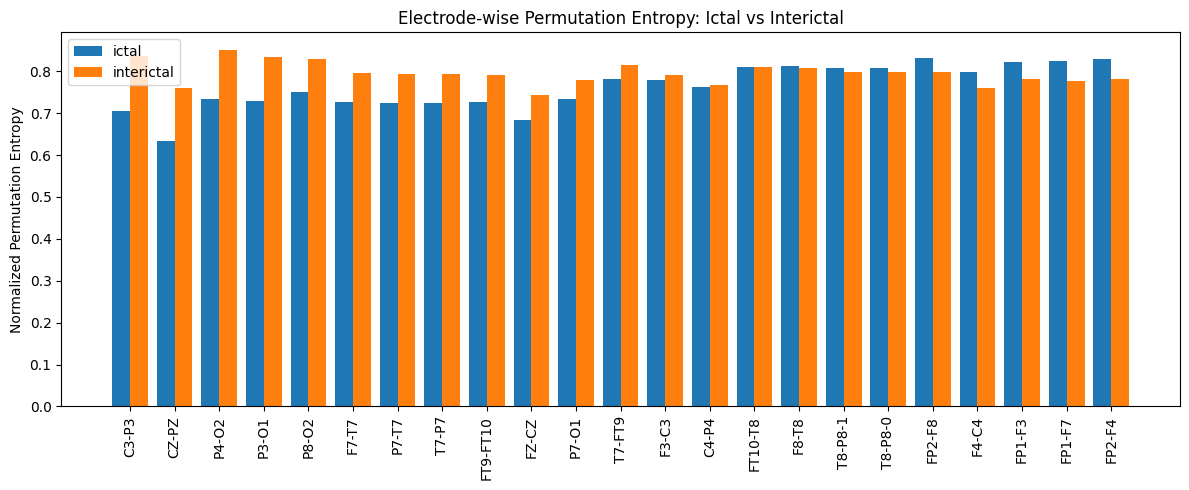

In [30]:
plt.figure(figsize=(12, 5))
x = np.arange(len(compare_entropy))
width = 0.4

plt.bar(x - width/2, compare_entropy["norm_permutation_entropy_ictal"], width=width, label="ictal")
plt.bar(x + width/2, compare_entropy["norm_permutation_entropy_interictal"], width=width, label="interictal")

plt.xticks(x, compare_entropy["electrode"], rotation=90)
plt.ylabel("Normalized Permutation Entropy")
plt.title("Electrode-wise Permutation Entropy: Ictal vs Interictal")
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
def compute_self_loop_stats(edges_df):
    df = edges_df.copy()
    df["is_self_loop"] = df["Source"] == df["Target"]

    out = (
        df.groupby("layer")
        .agg(
            total_weight=("weight", "sum"),
            self_loop_weight=("weight", lambda x: x[df.loc[x.index, "is_self_loop"]].sum())
        )
        .reset_index()
    )

    out["self_loop_ratio"] = out["self_loop_weight"] / out["total_weight"]
    return out

self_ictal = compute_self_loop_stats(edges_ictal).rename(columns={
    "layer": "electrode",
    "self_loop_ratio": "self_loop_ratio_ictal"
})

self_inter = compute_self_loop_stats(edges_inter).rename(columns={
    "layer": "electrode",
    "self_loop_ratio": "self_loop_ratio_interictal"
})

self_compare = self_ictal[["electrode", "self_loop_ratio_ictal"]].merge(
    self_inter[["electrode", "self_loop_ratio_interictal"]],
    on="electrode"
)

self_compare["diff"] = self_compare["self_loop_ratio_ictal"] - self_compare["self_loop_ratio_interictal"]
self_compare = self_compare.sort_values("diff", ascending=False)

display(self_compare)

,electrode,self_loop_ratio_ictal,self_loop_ratio_interictal,diff
0,C3-P3,0.675010,0.426672,0.248338
196,P4-O2,0.629644,0.394994,0.234650
180,P3-O1,0.639812,0.434102,0.205710
30,CZ-PZ,0.775909,0.582323,0.193586
233,P8-O2,0.596402,0.442706,0.153696
...,...,...,...,...
54,F4-C4,0.511537,0.579585,-0.068048
157,FP2-F8,0.432147,0.511928,-0.079781
100,FP1-F3,0.457176,0.538131,-0.080954
119,FP1-F7,0.451701,0.546734,-0.095033
